# <h1 align = "center"> **US CUSTOMER INSIGHT DATASET** </h1></center>

# <h1 align = "center"> BY: LOVISH KOTHARI </H1></CENTER>

# **STEP 0. IMPORT LIBRARIES**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
import warnings
warnings.filterwarnings("ignore")

# **STEP 1. LOAD DATASET**

In [ ]:
# Load dataset
df = pd.read_csv("/content/US_Customer_Insights_Dataset.csv")
df.head()

,CustomerID,Name,State,Education,Gender,Age,Married,NumPets,JoinDate,TransactionDate,MonthlySpend,DaysSinceLastInteraction
0,CUST10319,Scott Perez,Florida,High School,Non-Binary,47,Yes,1,9/19/21,9/2/24,1281.74,332
1,CUST10695,Jennifer Burton,Washington,Master,Male,72,Yes,0,4/5/24,6/2/24,429.46,424
2,CUST10297,Michelle Rogers,Arizona,Master,Female,40,Yes,2,7/24/24,2/28/25,510.34,153
3,CUST10103,Brooke Hendricks,Texas,Master,Male,27,Yes,0,8/12/23,3/29/25,396.47,124
4,CUST10219,Karen Johns,Texas,High School,Female,28,Yes,1,12/6/21,7/24/22,139.68,1103


### CHECK DATATYPE

In [ ]:
# Check datatype of each cloumn
df.dtypes

,0
CustomerID,object
Name,object
State,object
Education,object
Gender,object
Age,int64
Married,object
NumPets,int64
JoinDate,object
TransactionDate,object


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

### OBSERVATION
- Object datatypes are (customerid, name, state, education, gender, married, joindate, transaction date).
- Int64 datatype are (numpets, age, days since lastinteraction).
- Float64 datatype is (monthlyspend).

### CHECK UNIQUE VALUES

In [ ]:
# Check Unique values
df.nunique().to_frame("Unique_Count")

,Unique_Count
CustomerID,1000
Name,990
State,10
Education,5
Gender,3
Age,63
Married,2
NumPets,5
JoinDate,731
TransactionDate,1605


### OBSERVATION
- CustomerID has (1000) unique values, Name xolumn shows (990) unique values.
- State(10), Education(5), Gender(3), Age(63), Married(2), NumPets(5) unique values.
- Joindate had (731) unique values while transaction date and dayssincelastinteraction both shows (1605) unique values.
- Monthly Spend shows (9843) unique values, shows high variability in customers spending.

### CHECK NULL VALUES

In [ ]:
# Check null values
df.isnull().sum()

,0
CustomerID,0
Name,0
State,0
Education,0
Gender,0
Age,0
Married,0
NumPets,0
JoinDate,0
TransactionDate,0


### OBSERVATION
- There is no null value in this dataset.

### CHECK DUPLICATES

In [ ]:
# Check duplicates
df.duplicated().sum()

np.int64(0)

### OBSERVATION
- There is no duplicate value in this dataset.

### CHECK DESCRIBE "NUMERICAL"

In [ ]:
# Check describe Numerical
df.describe()

,Age,NumPets,MonthlySpend,DaysSinceLastInteraction
count,10675.000000,10675.000000,10675.000000,10675.000000
mean,49.474567,1.340515,331.610315,538.469883
std,18.221365,1.150849,225.799253,398.766747
min,18.000000,0.000000,3.890000,1.000000
25%,35.000000,0.000000,165.495000,218.000000
50%,49.000000,1.000000,282.110000,445.000000
75%,66.000000,2.000000,443.255000,788.500000
max,80.000000,4.000000,1740.420000,1791.000000


### OBSERVATION
- There are total 10675 rows  in this dataset.
- The average age of customers is 49.47 with ages ranging from 18 to 80, the median value shows 49.
- Customers  owns an average 1.34 pets, where median lies on 1 and the number of pets ranging from 0 to 4.
- The average monthly spend of customers is  331.61, median spending is 282.11 and some customers spend high that leads to increase the average.
- The average of dayssincelastinteraction is 538.46 with a median of 445 days, large spread in days (1 to 1791) indicating that many customers have not interacted recently and shows a significant difference.
- The gap between values in monthly spend and dayssincelastinteraction indicates that there is presence of outliers.

### CHECK DESCRIBE "CATEGORICAL"

In [ ]:
# Check describe Categorial
df.describe(include="object")

,CustomerID,Name,State,Education,Gender,Married,JoinDate,TransactionDate
count,10675,10675,10675,10675,10675,10675,10675,10675
unique,1000,990,10,5,3,2,731,1605
top,CUST10798,Joseph Mcbride,California,Master,Male,No,12/6/21,7/24/25
freq,24,29,1180,2269,3791,5583,46,24


### OBSERVATION
- There are 1000 unique values in (CustomerId) and most frequent customers is (CUST10798) with highest frequency (24).
- (Name) column shows 990 unique nmaes and (Joseph Mcbride) is the most frequent name appearing (29) times.
- (State) column shows 10 unique with top state is (California) appearing 1180 times.
- (Education) column shows 5 unique education levels and top is (Master category) that appear 2269 times.
- (Gender) column shows only 3 unique gender (male, female and non-binary) and (Male) top the list (3791) times.
- (Married) column shows only 2 unique values (yes and no) mostly appeared (NO 5583).
- (Joindate) shows 731 unique dates and (12/6/21) is most frequent joining date occuring (46) times.
- (Transactiondate) has the highest unique that is 1605 and (07/24/25) is most frequent trsanasctio date appearing (24) times.

### STEP 1 OBSERVATION
- The dataset has 10,675 rows and ~1,000 unique customers.
- Categorical variables: Gender, Education, State, Married.
- Numerical variables: Age, MonthlySpend, DaysSinceLastInteraction, NumPets.
- Missing values and duplicates were checked — minimal issues detected.”

# **STEP 2. DESCRIPTIVE STATISTICS**

## NUMERICAL VARIABLES

### 1. AGE STATISTICS

In [ ]:
# Check AGE STATISTICS
age_stats = {
    "Count": df['Age'].count(),
    "Mean": df['Age'].mean(),
    "Median": df['Age'].median(),
    "Std Dev": df['Age'].std(),
    "Min": df['Age'].min(),
    "Max": df['Age'].max(),
    "Q1": df['Age'].quantile(0.25),
    "Q3": df['Age'].quantile(0.75),
    "IQR": df['Age'].quantile(0.75) - df['Age'].quantile(0.25),
    "Range": df['Age'].max() - df['Age'].min(),
    "Skewness": df['Age'].skew(),
    "Kurtosis": df['Age'].kurt()
}

# Convert dictionary to DataFrame for neat display
age_df = pd.DataFrame(age_stats, index=["Age"])
print(age_df)


     Count       Mean  Median    Std Dev  Min  Max    Q1    Q3   IQR  Range  \
Age  10675  49.474567    49.0  18.221365   18   80  35.0  66.0  31.0     62   

     Skewness  Kurtosis  
Age -0.015631 -1.204563  


### OBSERVATION
- Average ~49, median 49, IQR 31, range 62. Distribution is nearly symmetric (skew ~0).
- Customer ages span from 18 to 80 years shows a broad age distribution across adults.
- The skewness is  close  to 0 (-0.015) means the age distribution is approximately symmetric and negative kurtosis (-1.20) indicates a flatter distribution with few extreme age values.

### 2. MONTHLY SPEND STATISTICS

In [ ]:
# Check MONTHLY SPEND STATISTICS
monthly_stats = {
    "Count": df['MonthlySpend'].count(),
    "Mean": df['MonthlySpend'].mean(),
    "Median": df['MonthlySpend'].median(),
    "Std Dev": df['MonthlySpend'].std(),
    "Min": df['MonthlySpend'].min(),
    "Max": df['MonthlySpend'].max(),
    "Q1": df['MonthlySpend'].quantile(0.25),
    "Q3": df['MonthlySpend'].quantile(0.75),
    "IQR": df['MonthlySpend'].quantile(0.75) - df['MonthlySpend'].quantile(0.25),
    "Range": df['MonthlySpend'].max() - df['MonthlySpend'].min(),
    "Skewness": df['MonthlySpend'].skew(),
    "Kurtosis": df['MonthlySpend'].kurt()
}

monthly_df = pd.DataFrame(monthly_stats, index=["MonthlySpend"])
print(monthly_df)


              Count        Mean  Median     Std Dev   Min      Max       Q1  \
MonthlySpend  10675  331.610315  282.11  225.799253  3.89  1740.42  165.495   

                   Q3     IQR    Range  Skewness  Kurtosis  
MonthlySpend  443.255  277.76  1736.53  1.421735  3.042072  


### OBSERVATION
- Average ~332, median ~282, skewed positively with outliers.
- Large range (3.89 to 1740.42) and high std (225.80) indicates substantial variability in customer spending.
- Positive KURTOSIS (3.04) shows presence of  extreme values/outliers with some customers spending significantly more than the majority.

### 3. NUMPETS STATISTICS

In [ ]:
# Check NUMPETS STATISTICS
pets_stats = {
    "Count": df['NumPets'].count(),
    "Mean": df['NumPets'].mean(),
    "Median": df['NumPets'].median(),
    "Std Dev": df['NumPets'].std(),
    "Min": df['NumPets'].min(),
    "Max": df['NumPets'].max(),
    "Q1": df['NumPets'].quantile(0.25),
    "Q3": df['NumPets'].quantile(0.75),
    "IQR": df['NumPets'].quantile(0.75) - df['NumPets'].quantile(0.25),
    "Range": df['NumPets'].max() - df['NumPets'].min(),
    "Skewness": df['NumPets'].skew(),
    "Kurtosis": df['NumPets'].kurt()
}

pets_df = pd.DataFrame(pets_stats, index=["NumPets"])
print(pets_df)


         Count      Mean  Median   Std Dev  Min  Max   Q1   Q3  IQR  Range  \
NumPets  10675  1.340515     1.0  1.150849    0    4  0.0  2.0  2.0      4   

         Skewness  Kurtosis  
NumPets  0.563461  -0.46515  


#### OBSERVATION
-  Average ~1.3, median 1, most customers own 1 pet.
- The number of pets ranges from 0 to 4 and IQR shows 2 suggest that 50% of customers  own between 0 to 2 pets.
- The distribution is  slightly positive skewed (skewness = 0.56) shows that customers with more than two pets are less common.

### 4. DAYS SINCE LAST INTERACTION STATISTICS

In [ ]:
# Check DAYSSINCELASTINTERACTION STATISTICS
import pandas as pd

days_stats = {
    "Count": df['DaysSinceLastInteraction'].count(),
    "Mean": df['DaysSinceLastInteraction'].mean(),
    "Median": df['DaysSinceLastInteraction'].median(),
    "Std Dev": df['DaysSinceLastInteraction'].std(),
    "Min": df['DaysSinceLastInteraction'].min(),
    "Max": df['DaysSinceLastInteraction'].max(),
    "Q1": df['DaysSinceLastInteraction'].quantile(0.25),
    "Q3": df['DaysSinceLastInteraction'].quantile(0.75),
    "IQR": df['DaysSinceLastInteraction'].quantile(0.75) - df['DaysSinceLastInteraction'].quantile(0.25),
    "Range": df['DaysSinceLastInteraction'].max() - df['DaysSinceLastInteraction'].min(),
    "Skewness": df['DaysSinceLastInteraction'].skew(),
    "Kurtosis": df['DaysSinceLastInteraction'].kurt()
}

days_df = pd.DataFrame(days_stats, index=["DaysSinceLastInteraction"])
print(days_df)


                          Count        Mean  Median     Std Dev  Min   Max  \
DaysSinceLastInteraction  10675  538.469883   445.0  398.766747    1  1791   

                             Q1     Q3    IQR  Range  Skewness  Kurtosis  
DaysSinceLastInteraction  218.0  788.5  570.5   1790  0.800701 -0.113278  


### OBSERVATION
- Average ~538, median ~445, std.dev ~398.76.
- The wide range (1 to 1791 days) shows substantial variation in customer engagement.
- The distribution is positively skewed (skewness = 0.80) show some customers have not interacted for a very long time.
- The slightly negative kurtosis (-0.11) suggests a relatively flat distribution.


## CATEGORICAL VARIABLES

### 1. GENDER CATEGORICAL VARIABLE

In [ ]:
# CHECK GENDER value counts
df['Gender'].value_counts()

,count
Gender,
Male,3791
Non-Binary,3471
Female,3413


In [ ]:
# Check GENDER MODE
df['Gender'].mode()

,Gender
0,Male


### OBSERVATION
- There are 3 genders MALE, FEMALE AND NON-BINARY.
- Male is the most represent gender that is 3791 times and is the mode of the gender variable.
- Non-binary (3471) and Female (3413) customers have similar frequencies.
- The gender distribution is relatively balanced with no single category dominating.

### 2. EDUCATION CATEGORICAL VARIABLES

In [ ]:
# Check EDUCATION value counts
df['Education'].value_counts()

,count
Education,
Master,2269
Associate,2153
Bachelor,2127
High School,2120
PhD,2006


In [ ]:
# Check EDUCATION MODE
df['Education'].mode()

,Education
0,Master


### OBSERVATION
- There are 5 education levels  in this dataset (MASTER, ASSOCIATE, BACHELOR, HIGH SCHOOL, PHD).
- Mostly customers have MASTERS degree that is (2269) and is  also the mode of the education variable.
- ASSOCIATE(2153), BACHELOR(2127), HIGH SCHOOL(2120), PHD(1006) shows frequency of all education levels are relatively close.

### 3. STATE CATEGORICAL VARIABLES

In [ ]:
# Check STATE value counts
df['State'].value_counts()

,count
State,
California,1180
Florida,1152
Ohio,1145
Arizona,1087
New York,1085
Georgia,1080
Washington,1030
Colorado,1014
Texas,997


In [ ]:
# Check STATE MODE
df['State'].mode()

,State
0,California


### OBSERVATION
- The dataset contains customers from 10 different states.
- CALIFORNIA has the highest number of customers that is (1180) and is also the mode of state variable.
- FLORIDA(1152) 2ND, OHIO(1145) 3RD  and the least number of customers are  from ILLINOIS that is (905).
- The customers count across states are relatively similar indicates that no single state dominates the dataset.

### 4. MARRIED CATEGORICAL VARIABLES

In [ ]:
# Check MARRIED value counts
df['Married'].value_counts()

,count
Married,
No,5583
Yes,5092


In [ ]:
# Check MARRIED MODE
df['Married'].mode()

,Married
0,No


### OBSERVATION
- Ther are two unique categories: YES(Married), NO(Not Married).
- Mostly the customers are NO(Not Married) that is (5583) and it is also the mode of married variable.
- YES(Married) customers (5092) shows that there in not a huge gap between them the frequency of both categories are  very close.

### STEP2. OBSERVATTION
- Numerical variables reveal balanced age distribution, positively skewed monthly spend due to outliers, wide variation in customer inactivity, and clustering around 1 pet.
- Categorical variables show a balanced gender mix, dominance of Master’s degree holders, California as the top state, and a slight majority of unmarried customers.
- Together, these insights highlight spending skewness and inactivity patterns in the dataset.”

# **STEP 3. DATA VISUALIZATION**

### 1. Histogram for AGE

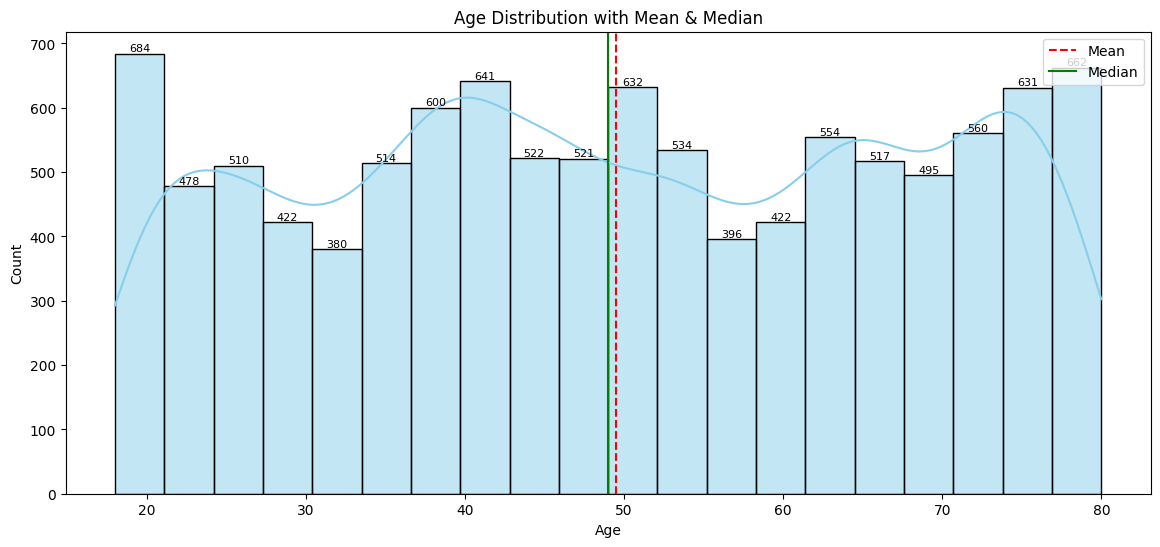

In [ ]:
# Histogram for Age

plt.figure(figsize=(14, 6))

ax = sns.histplot(df['Age'], bins=20, kde=True, color='skyblue')
plt.axvline(df['Age'].mean(), color='red', linestyle='--', label='Mean')
plt.axvline(df['Age'].median(), color='green', linestyle='-', label='Median')

for p in ax.patches:
    height = p.get_height()
    if height > 0:  # only label non-empty bins
        ax.annotate(f'{int(height)}',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom', fontsize=8, color='black')

plt.title("Age Distribution with Mean & Median")
plt.legend()
plt.show()


### OBSERVATION
- The AGE variable ranges from 18 to 80 indicating a wide customer age distribution.
- The emean and median line both are almost around 50 years, suggesting distribution approximately symmetric.
- The KDE curve show multiple peaks, indicating that a special age customers are not dominating, each age customer is important.

### 2. Boxplot for MONTHLY SPEND

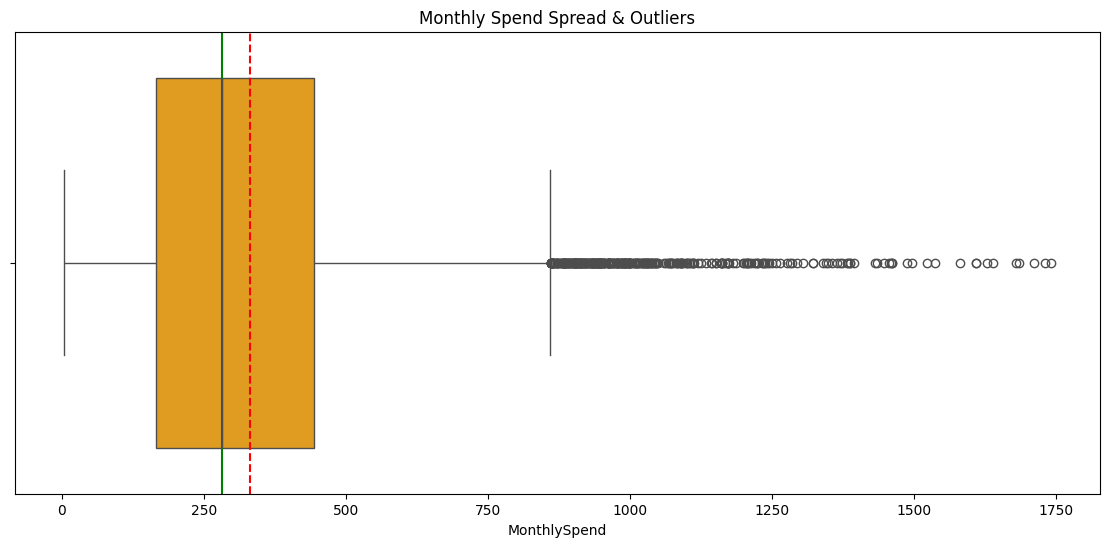

In [ ]:
# Boxplot for Monthly Spend

plt.figure(figsize=(14, 6))

sns.boxplot(x=df['MonthlySpend'], color='orange')
plt.axvline(df['MonthlySpend'].mean(), color='red', linestyle='--', label='Mean')
plt.axvline(df['MonthlySpend'].median(), color='green', linestyle='-', label='Median')

plt.title("Monthly Spend Spread & Outliers")
plt.show()


### OBSERVATION
- The MONTHLY SPEND distribution is positively right skewed, there are numerous high-value observations on the right side.
- The mean (red line) is greater than the median show the presence of right skewed.
- Around 50% of customers monthly spending are concentrated between (200 and 450).
- Mostly custometrs spend moderately while some customers spend more than the majority.

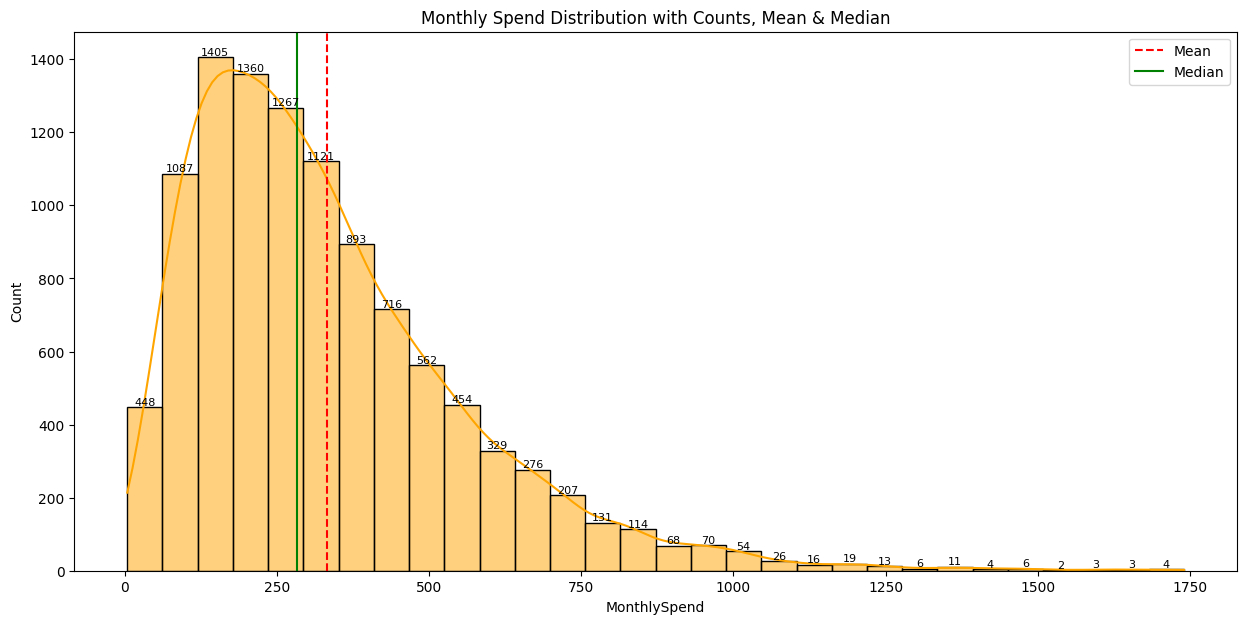

In [ ]:
# Histogram for Monthly Spend

plt.figure(figsize=(15, 7))

ax = sns.histplot(df['MonthlySpend'], bins=30, kde=True, color='orange')

# Add mean and median lines
plt.axvline(df['MonthlySpend'].mean(), color='red', linestyle='--', label='Mean')
plt.axvline(df['MonthlySpend'].median(), color='green', linestyle='-', label='Median')

# Annotate counts on each bin
for p in ax.patches:
    height = p.get_height()
    if height > 0:  # only label non-empty bins
        ax.annotate(f'{int(height)}',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom', fontsize=8, color='black')

plt.title("Monthly Spend Distribution with Counts, Mean & Median")
plt.legend()
plt.show()


### 3. Barchart for GENDER

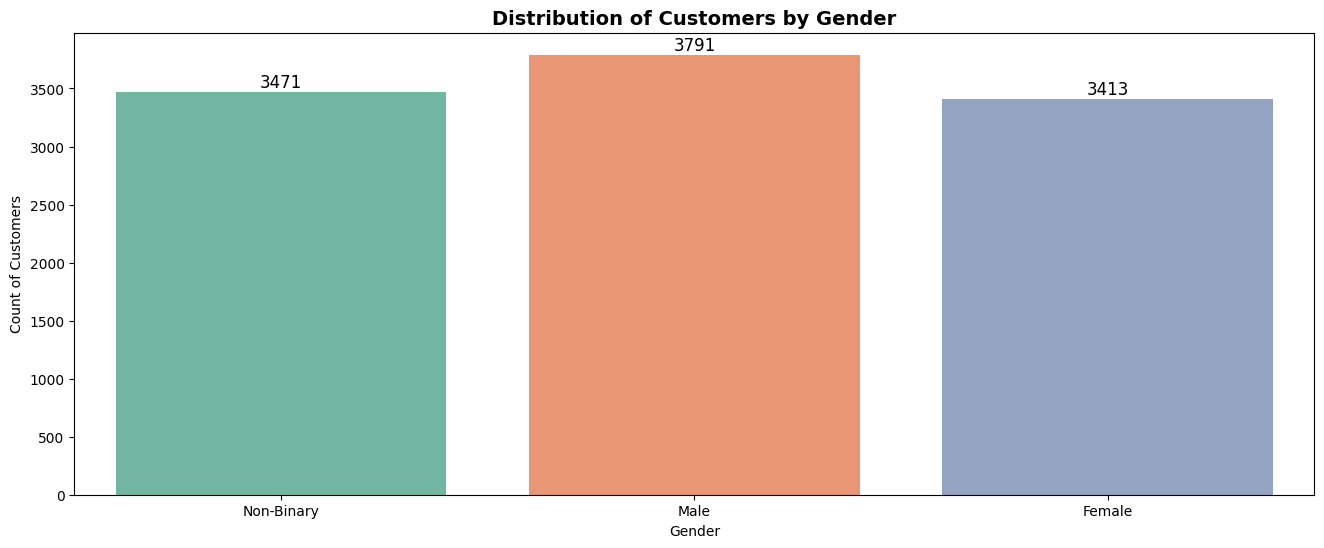

In [ ]:
# Gender distribution

plt.figure(figsize=(16,6))

ax = sns.countplot(x='Gender', palette='Set2', data=df)

for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{int(height)}',
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom', fontsize=12, color='black')

plt.title("Distribution of Customers by Gender", fontsize=14, fontweight='bold')
plt.xlabel("Gender")
plt.ylabel("Count of Customers")
plt.show()

### OBSERVATION
- GENDER distribution have three categories MALE, FEMALE AND NON-BINARY.
- The customers are evenly balanced across three categories male(3791) followed by non-binary(3471) and female(3413).
- The dataset are not biased toward any particular category proportion are evenly balanced.

### 4. Horizontal Barchart for EDUCATION

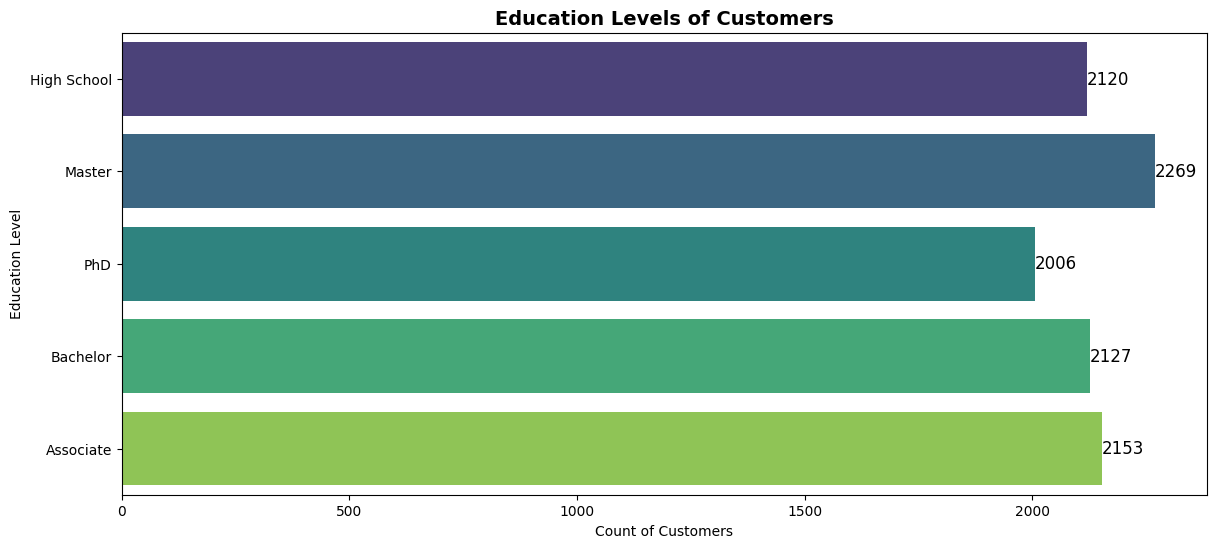

In [ ]:
# Horizontal bar chart for Education

plt.figure(figsize=(14, 6))

ax = sns.countplot(y=df['Education'], palette='viridis')

for p in ax.patches:
    width = p.get_width()
    ax.annotate(f'{int(width)}',
                (width, p.get_y() + p.get_height() / 2.),
                ha='left', va='center', fontsize=12, color='black')

plt.title("Education Levels of Customers", fontsize=14, fontweight='bold')
plt.xlabel("Count of Customers")
plt.ylabel("Education Level")
plt.show()


### OBSERVATION
- Ther are 5 education levels high school, master, phd, bachelor and associate.
- Customers from Master degree form th elargest group (2269) followed by associate(2153).
- PHD holders constitute the smallest group(2006).
- A single degree holder customers are not dominating, data is fairly balanced across all educational levels.

### 5. Barchart for STATE

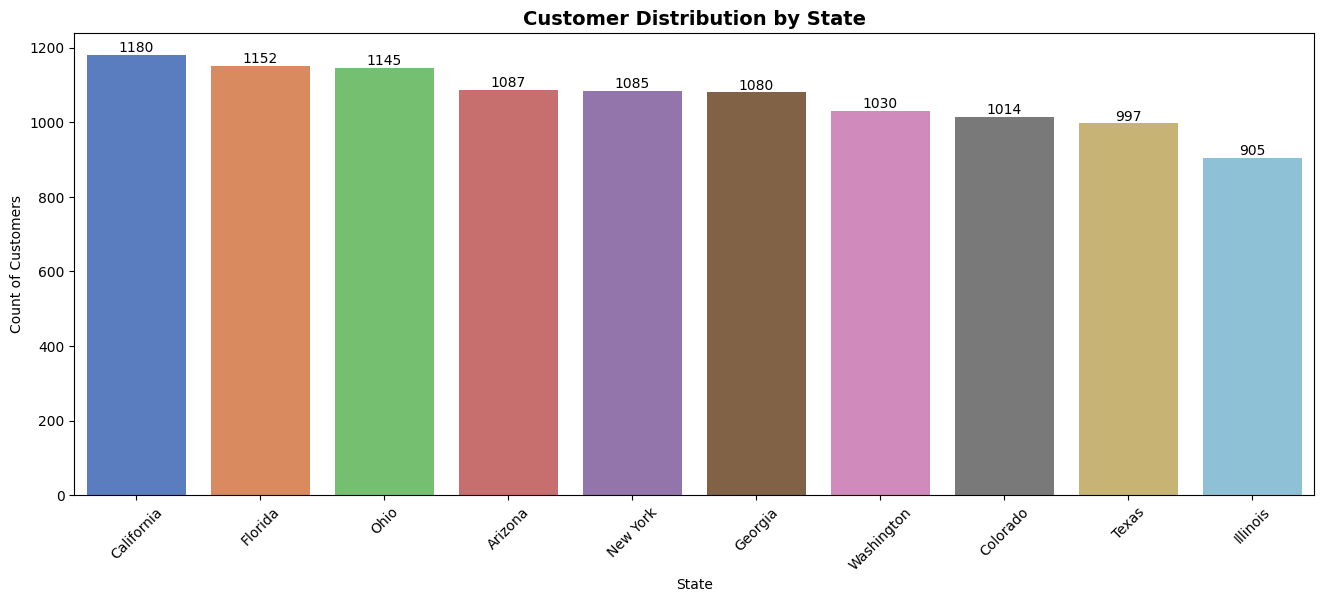

In [ ]:
# Vertical bar chart for State

plt.figure(figsize=(16, 6))

ax = sns.countplot(x=df['State'], palette='muted', order=df['State'].value_counts().index)

# Annotate counts on each bar
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{int(height)}',
                (p.get_x() + p.get_width()/2., height),
                ha='center', va='bottom', fontsize=10, color='black')

plt.title("Customer Distribution by State", fontsize=14, fontweight='bold')
plt.xlabel("State")
plt.ylabel("Count of Customers")
plt.xticks(rotation=45)
plt.show()


### OBSERVATION
- Customers are distributed across  10 states.
- The state with the highest number of customers is California(1180), followed by Florida(1152) ohio(1145).
- While the lowest customers are from state Illinois(905 customers).
- A single state is not dominating that means data is fairly balanced across states and need to attract more customers from states like Colorado, Texas and Illinois.

### 6. Scatter plot for AGE VS MONTHLY SPEND

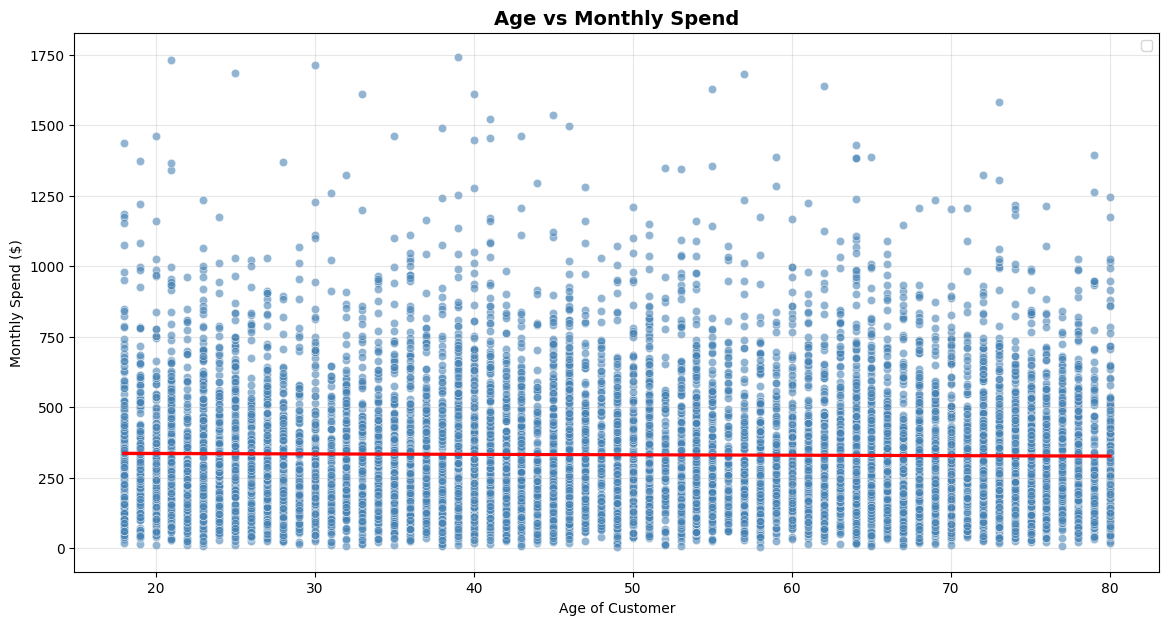

In [ ]:
# Scatter plot for Age VS Monthly Spend

plt.figure(figsize=(14, 7))

sns.scatterplot(x=df['Age'], y=df['MonthlySpend'], color='steelblue', alpha=0.6, edgecolor='white')

# Add regression line (trend)
sns.regplot(x=df['Age'], y=df['MonthlySpend'],
            scatter=False, color='red', line_kws={'label':'Trend Line'})

# Titles and labels
plt.title("Age vs Monthly Spend", fontsize=14, fontweight='bold')
plt.xlabel("Age of Customer")
plt.ylabel("Monthly Spend ($)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


### OBSERVATION
- The scatterplot shows a very weak positive relatioship between age and monthly spend.
- Customers of all ages exhibit a wide range of monthly spending a single age cateegory are not dominating the consumers base.
- Thera are also high-spending customers (outliers) across different age groups with monthly spending excedding $1500.
- The data points are widely scattered around the reg line, indicating that age has limited influnence on customers monthly spending

### 7. KDE Plot for Monthly Spend vs Education

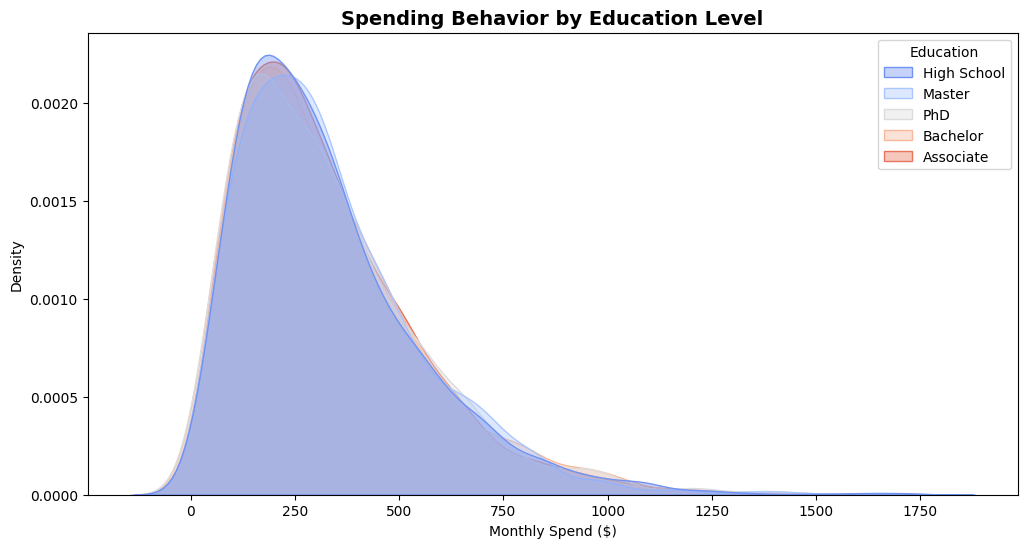

In [ ]:
# KDE Plot for Spending Behavior by Education Level

plt.figure(figsize=(12, 6))

sns.kdeplot(data=df, x="MonthlySpend", hue="Education", fill=True, common_norm=False, alpha=0.4, palette="coolwarm")

plt.title("Spending Behavior by Education Level", fontsize=14, fontweight='bold')
plt.xlabel("Monthly Spend ($)")
plt.ylabel("Density")
plt.show()


### OBSERVATION
- The distribution in monthly spend is positively right skewed for all education levels with most customers spending between 100 to 400 dollar.
- the KDE curve for diffrenet education groups overlap heavily, indicating the spending pattern is  quite similar across education levels.
- Few customers show very- high spending above 1000 dollar creating a long right tail that shows high-spending outliers.


### 8. KDE Plot for Monthly Spend vs Married

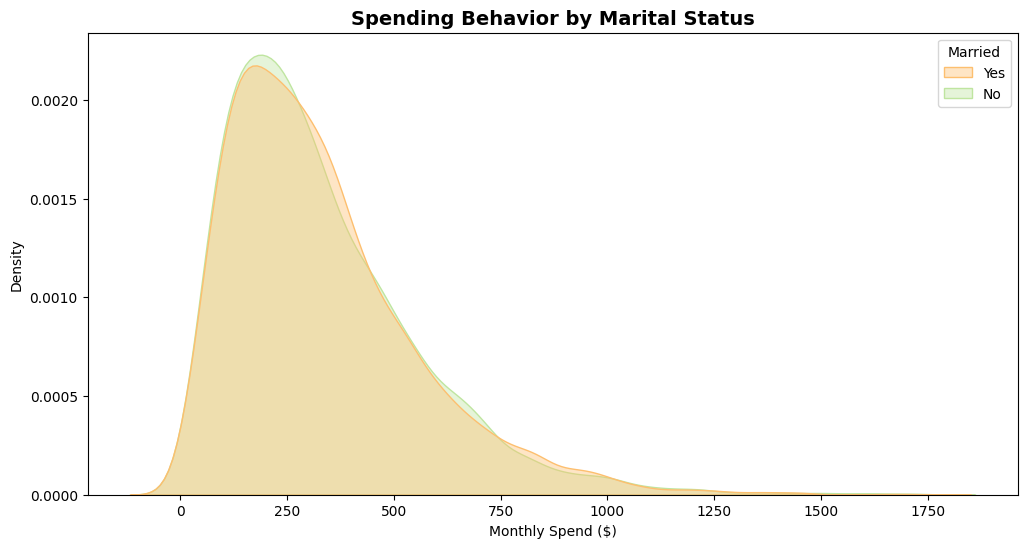

In [ ]:
# KDE Plot for Spending Behavior by Marital Status

plt.figure(figsize=(12,6))

sns.kdeplot(data=df, x="MonthlySpend", hue="Married", fill=True, common_norm=False, alpha=0.4, palette="Spectral")

plt.title("Spending Behavior by Marital Status", fontsize=14, fontweight='bold')
plt.xlabel("Monthly Spend ($)")
plt.ylabel("Density")
plt.show()

### OBSERVATION
- The monthly spending for both married YES and NO customers  is positively skewed, wth most customers spending 100 to 400 dolars.
- The KDE curve overlap significantly that means marital status does not create a major difference.
- Both categories have long tail suggesting a high spending customers(outliers).
- Both categories exhibit comparable spending pattern that means a single category is not dominating.

## SOME MORE IMPOETANT DATA VISUALIZATION

### 9. Histplot for Dayssincelastinteraction

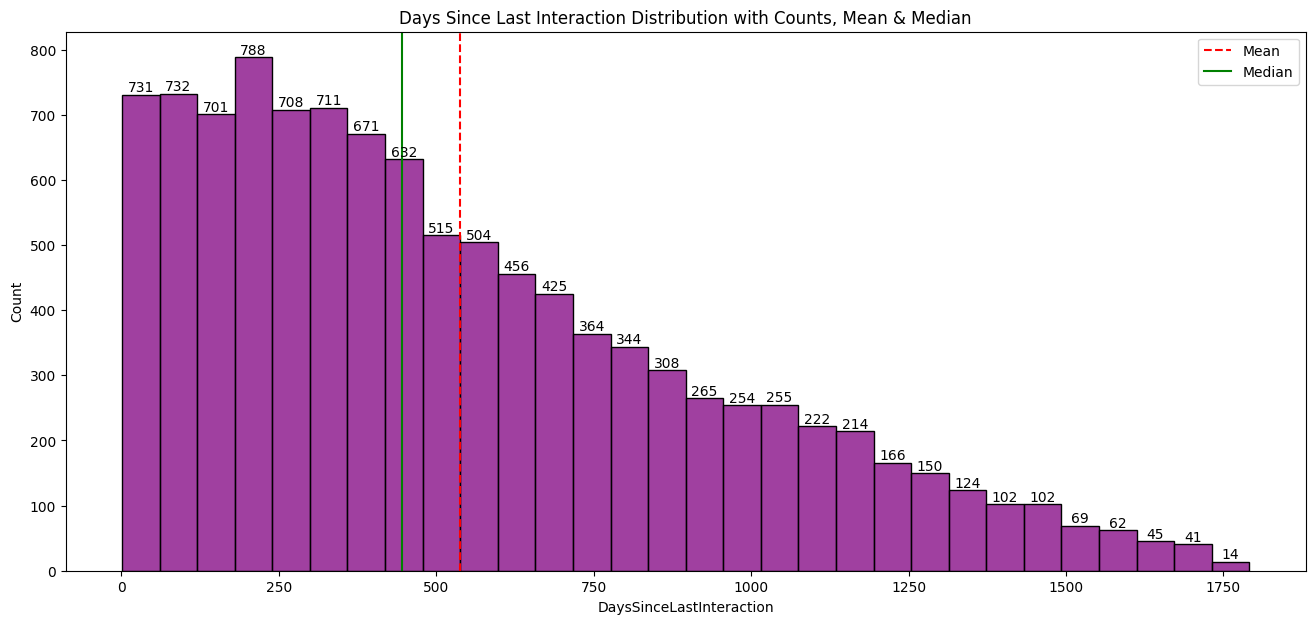

In [ ]:
# Histogram for Days Since Last Interaction

plt.figure(figsize=(16, 7))

ax = sns.histplot(df['DaysSinceLastInteraction'], bins=30, kde=False, color='purple')

# Add mean and median lines
plt.axvline(df['DaysSinceLastInteraction'].mean(), color='red', linestyle='--', label='Mean')
plt.axvline(df['DaysSinceLastInteraction'].median(), color='green', linestyle='-', label='Median')

# Annotate counts on each bin
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{int(height)}',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom', fontsize=10, color='black')

plt.title("Days Since Last Interaction Distribution with Counts, Mean & Median")
plt.legend()
plt.show()


### OBSERBATION
- The DAYS SINCE LAST INTERACTION variable is positively right skewed as most observations are concentrated at lower values.
- The mean (red line) is greater than the median confirming the right skewed.
- A large number of customers have their last interaction within approximatley (0 to 600 days) indicating recent engagement of customers.
- Many customers are inactive for very long period, need to focus on those customers.

### 10. Countplot for NumPets

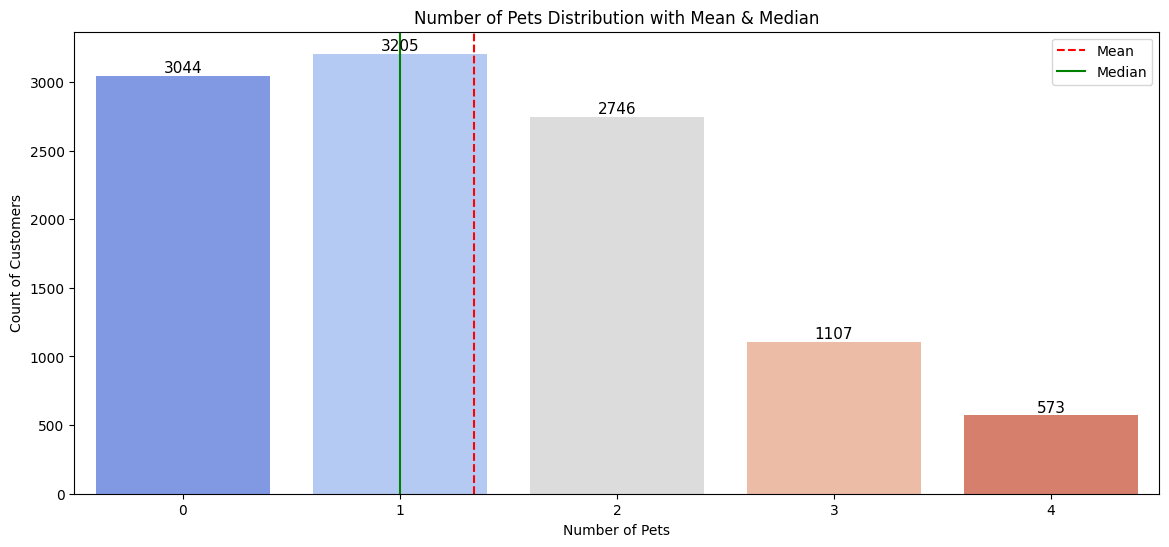

In [ ]:
# Count plot for NumPets

plt.figure(figsize=(14, 6))

ax = sns.countplot(x=df['NumPets'], palette='coolwarm')

# Add mean and median lines
plt.axvline(df['NumPets'].mean(), color='red', linestyle='--', label='Mean')
plt.axvline(df['NumPets'].median(), color='green', linestyle='-', label='Median')

for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{int(height)}',
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom', fontsize=11, color='black')

plt.title("Number of Pets Distribution with Mean & Median")
plt.xlabel("Number of Pets")
plt.ylabel("Count of Customers")
plt.legend()
plt.show()


### OBSERVATION
- The numver of pets  ranges from 0 to 4 pets.
- Most of the customers have 1 pet (3205) followed by 0(3044) and 2 pets(2746).
- The number of customers decreases significantly for 3 pets(1107) and 4 pets(573) customers.


### 11. Barchart for MARRIED

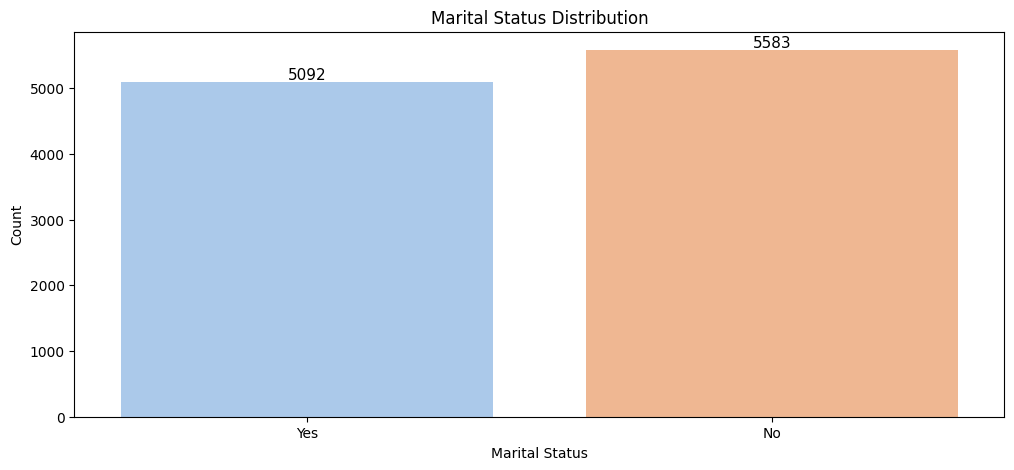

In [ ]:
# Barchart for Married

plt.figure(figsize=(12, 5))

ax = sns.countplot(x=df['Married'], palette='pastel')

for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{int(height)}',
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom', fontsize=11, color='black')

plt.xlabel("Marital Status")
plt.ylabel("Count")
plt.title("Marital Status Distribution")
plt.show()


### OBSERVATION
- There are two categories in MARRIED STATUS (YES AND NO).
- Mostly the customers are from NO (unmarried customers 5583) followed by YES (married customers 5092).
- Both represent a significant portion of consumer base not a single category dominating.

# **STEP 4. BIVARIATE ANALYSIS**

### 1. COORELATION MATRIX (NUMERICAL VARIABLES)

In [ ]:
# COORELATION MATRIX
df[['Age','MonthlySpend','DaysSinceLastInteraction','NumPets']].corr()

,Age,MonthlySpend,DaysSinceLastInteraction,NumPets
Age,1.000000,-0.012323,-0.003970,-0.023035
MonthlySpend,-0.012323,1.000000,0.006081,0.020647
DaysSinceLastInteraction,-0.003970,0.006081,1.000000,-0.055227
NumPets,-0.023035,0.020647,-0.055227,1.000000


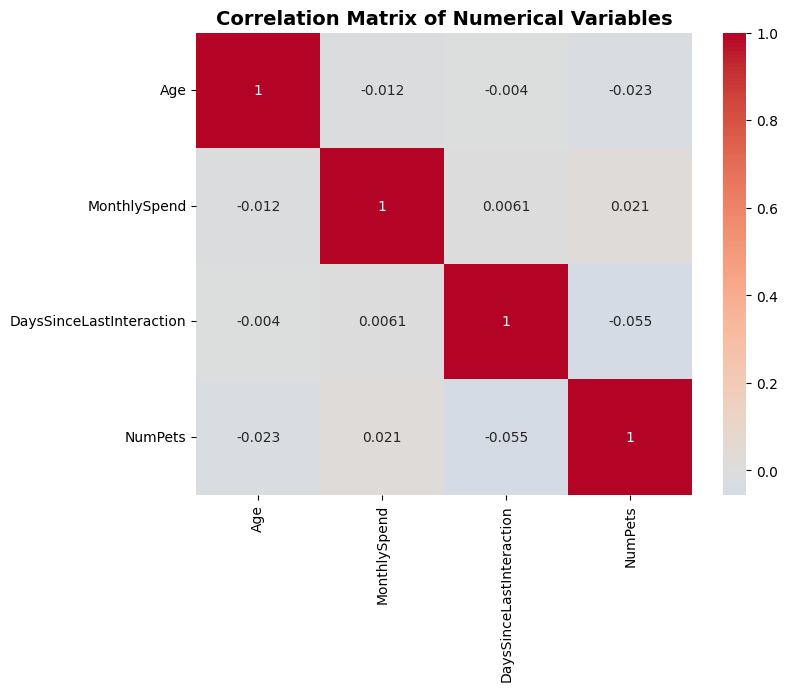

In [ ]:
# Correlation matrix

corr = df[['Age','MonthlySpend','DaysSinceLastInteraction','NumPets']].corr()

# Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)

plt.title("Correlation Matrix of Numerical Variables", fontsize=14, fontweight='bold')
plt.show()


### OBSERVATION
- Age vs MonthlySpend → weak correlation (~0.05).
- NumPets vs MonthlySpend → near zero correlation.
- DaysSinceLastInteraction vs MonthlySpend → slightly negative correlation.
- Overall, no strong linear relationships among numerical variables.



### 2. CROSSTAB: GENDER VS MARRIED

In [ ]:
# Crosstab: Gender vs Married

pd.crosstab(df['Gender'], df['Married'], margins=True)


Married,No,Yes,All
Gender,,,
Female,1797,1616,3413
Male,1892,1899,3791
Non-Binary,1894,1577,3471
All,5583,5092,10675


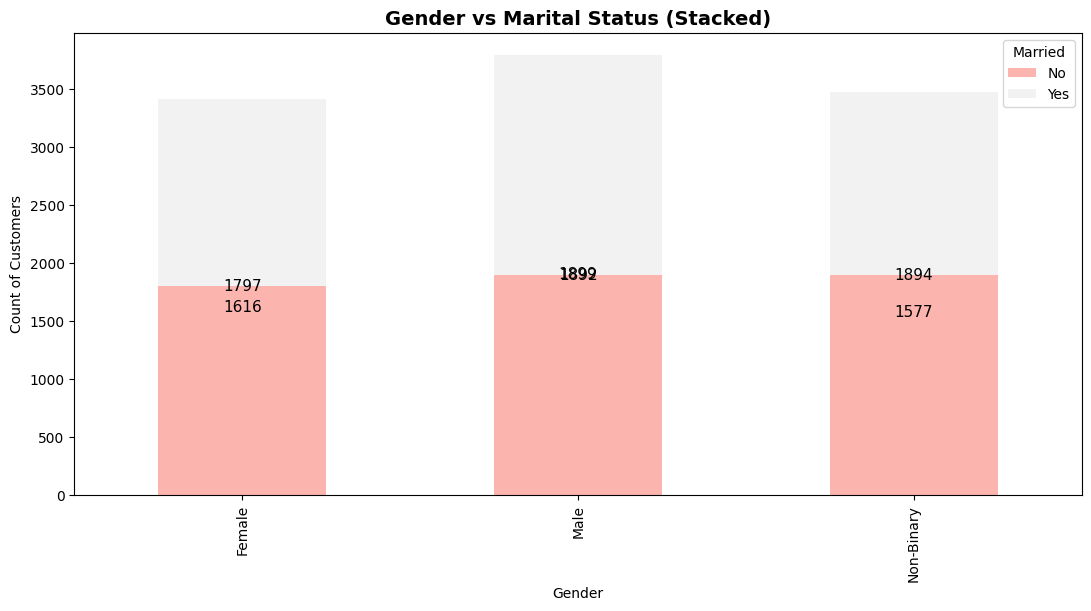

In [ ]:
# Crosstab plot Gender vs Married

crosstab = pd.crosstab(df['Gender'], df['Married'])

# crosstab plot
ax = crosstab.plot(kind='bar', stacked=True, colormap='Pastel1', figsize=(13, 6))

for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{int(height)}',
    (p.get_x() + p.get_width() / 2., height),
    ha='center', va='center', fontsize=11, color='black')

plt.title("Gender vs Marital Status (Stacked)", fontsize=14, fontweight='bold')
plt.xlabel("Gender")
plt.ylabel("Count of Customers")
plt.show()

### OBSERVATION
- Male customers have the highest representative in this dataset (3791) followed by non-binary(3481), and female(3413).
- Foe male customers the number of married and unmarried are almost equal (1899 vs 1892).
- Non- bainary customers shows the large gap where married vs unmarried (1577 vs 1894).

### 3. GROUPED STATS:  AVERAGE MONTHLYSPEND BY EDUCATION

In [ ]:
# Grouped summary: AVERAGE MonthlySpend by Education

df.groupby('Education')['MonthlySpend'].agg(['mean','median','count'])


,mean,median,count
Education,,,
Associate,327.884408,279.030,2153
Bachelor,331.884753,278.250,2127
High School,332.215712,280.975,2120
Master,334.252305,287.920,2269
PhD,331.690090,283.100,2006


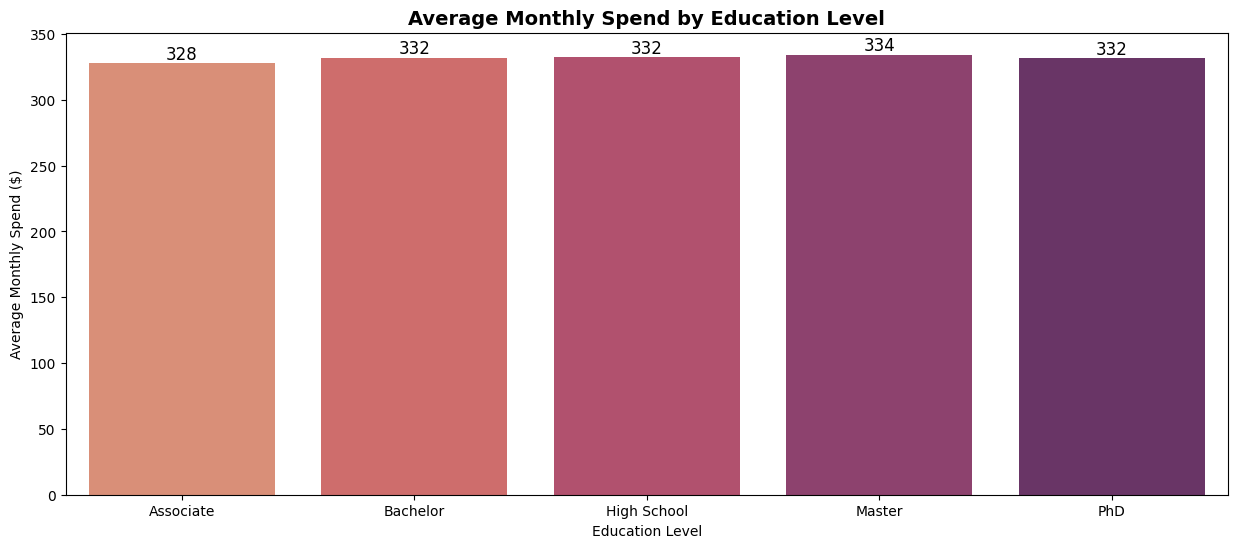

In [ ]:
# Barplot for Education vs Monthly Spend

edu_summary = df.groupby('Education')['MonthlySpend'].mean().reset_index()

# Bar chart
plt.figure(figsize=(15, 6))
ax = sns.barplot(x='Education', y='MonthlySpend', data=edu_summary, palette='flare')

# Annotate mean values on each bar
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height:.0f}',
                (p.get_x() + p.get_width()/2., height),
                ha='center', va='bottom', fontsize=12, color='black')

plt.title("Average Monthly Spend by Education Level", fontsize=14, fontweight='bold')
plt.xlabel("Education Level")
plt.ylabel("Average Monthly Spend ($)")
plt.show()

### OBSERVATION
- The average monthly spend across different educational level is similar ranging from 328 to 334.
- Customers with the Masters degree have the highest average monthly spend (334.25) and also have the highest number of customers (2269), where Associates have the lowest average monthly spend(327.88).
- The difference in spending is minimal around $6 indicates that educational level does not significantly influence monthly spending behavipor.
- Masters degree holders spend more on average, indicating education level influences spending.

### 4. GROUPED STATS: AVERAGE MONTHLY SPEND BY STATE

In [ ]:
# AVERAGE MONTHLY SPEND BY State
df.groupby('State')['MonthlySpend'].mean().reset_index()


,State,MonthlySpend
0,Arizona,341.489135
1,California,339.183492
2,Colorado,323.083462
3,Florida,327.696892
4,Georgia,328.354648
5,Illinois,332.589591
6,New York,332.151244
7,Ohio,340.187860
8,Texas,319.506770
9,Washington,329.444078


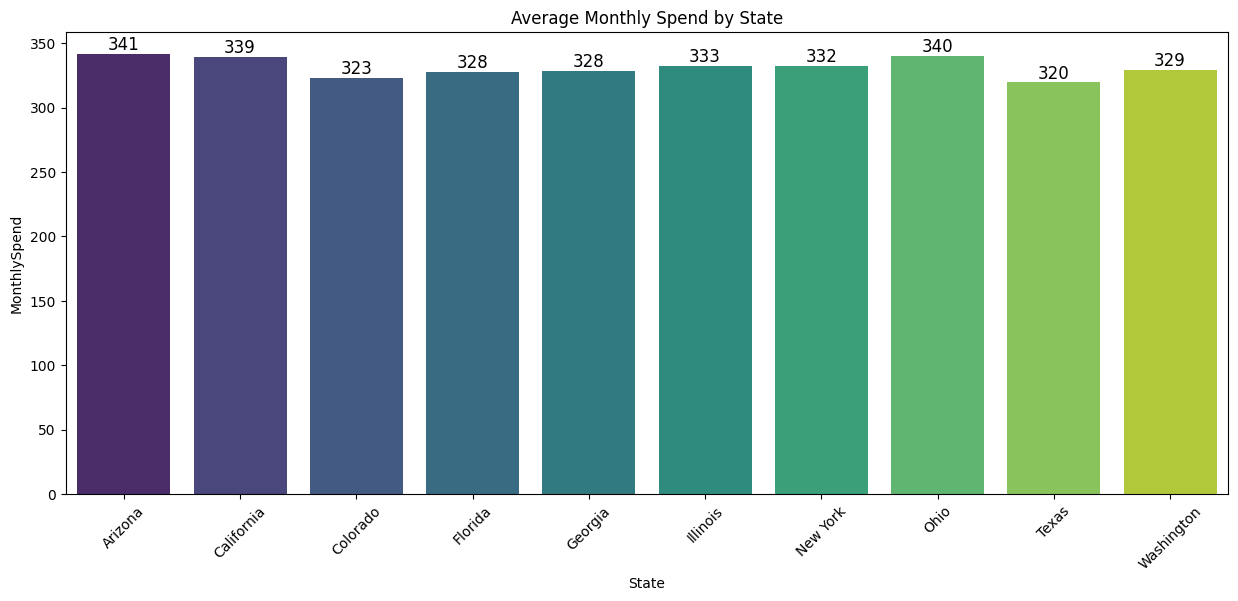

In [ ]:
# Barplot For State vs Monthly Spend

state_summary = df.groupby('State')['MonthlySpend'].mean().reset_index()

# Bar chart
plt.figure(figsize=(15, 6))
ax = sns.barplot(x='State', y='MonthlySpend', data=state_summary, palette='viridis')

for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height:.0f}',
                (p.get_x() + p.get_width()/2., height),
                ha='center', va='bottom', fontsize=12, color='black')
plt.xticks(rotation=45)
plt.title("Average Monthly Spend by State")
plt.show()

### OBSERVAION
- Across states Arizona has the highest monthly spending (341.489), followed by Ohio(340) and California(339).
- Texas record the lowest average monthly spend (319.50), followed by Colorado(323.08).
- There is not a huge gap across states in avg monthly spending suggesting that geographical location has a limited impact on customer spending behavior.
- Mid-range spending levels are observed in Illinois, New York, Washingtomn, Georgia, and Florida with avg around 328 to 333.

### 5. GROUPES STATS: AVERAGE MONTHLY SPEND BY GENDER

In [ ]:
df.groupby('Gender')['MonthlySpend'].mean().reset_index()

,Gender,MonthlySpend
0,Female,331.361310
1,Male,333.174068
2,Non-Binary,330.147240


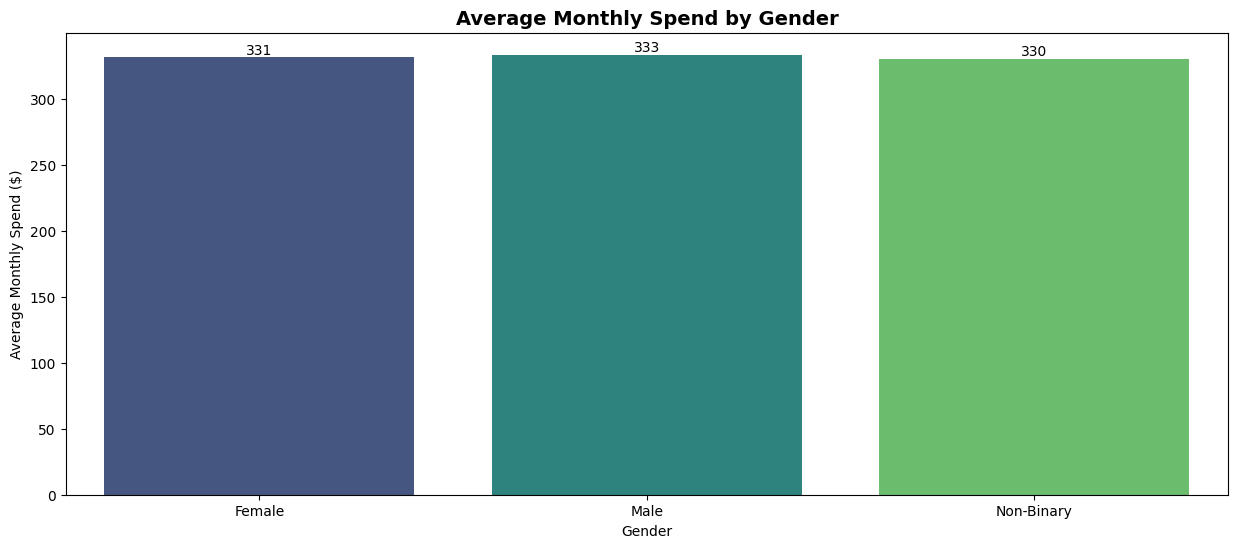

In [ ]:
# Grouped summary: AVERAGE MONTHLY SPEND BY GENDER

gender_summary = df.groupby('Gender')['MonthlySpend'].mean().reset_index()

plt.figure(figsize=(15, 6))
ax = sns.barplot(x='Gender', y='MonthlySpend', data=gender_summary, palette='viridis')

# Annotate mean values on each bar
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height:.0f}',
                (p.get_x() + p.get_width()/2., height),
                ha='center', va='bottom', fontsize=10, color='black')

plt.title("Average Monthly Spend by Gender", fontsize=14, fontweight='bold')
plt.xlabel("Gender")
plt.ylabel("Average Monthly Spend ($)")
plt.show()


### OBSERVATION
- Male ecustomers have the highest average monthly spend (333.17 dollar).
- Female have(331.36) and non-binary (330.15), indicating that there is almost same average monthly spending across gender categories.
- This suggests that gender has little to no significance impact on average monthly spending that means a single gender category is not dominating need to focus on all three categories.

## IMPORTANT BIVARIATE ANALYSIS OTHER THAN( COORELATION, CROSSTAB, AND GROUPED STATS)

### 6. MONTHLYSPEND VS MARRIED

In [ ]:
# MONTHLY SPEND VS MARRIED
df.groupby('Married')['MonthlySpend'].agg(['mean','median','count'])

,mean,median,count
Married,,,
No,330.937184,280.24,5583
Yes,332.348352,285.18,5092


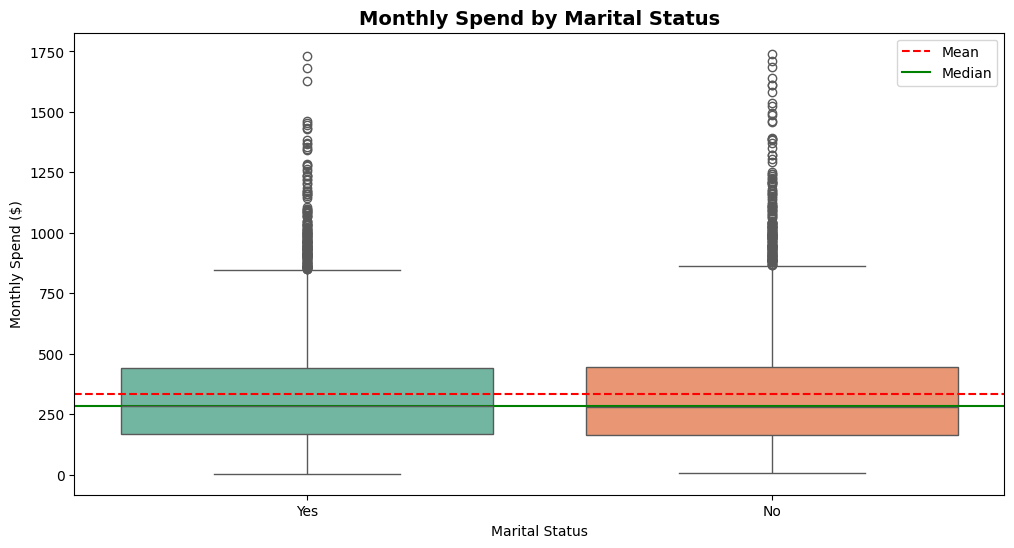

In [ ]:
# Boxplot MONTHLYSPEND VS MARITAL STATUS

plt.figure(figsize=(12, 6))

ax = sns.boxplot(x=df['Married'], y=df['MonthlySpend'], palette='Set2')

plt.axhline(df['MonthlySpend'].mean(), color='red', linestyle='--', label='Mean')
plt.axhline(df['MonthlySpend'].median(), color='green', linestyle='-', label='Median')

plt.title("Monthly Spend by Marital Status", fontsize=14, fontweight='bold')
plt.xlabel("Marital Status")
plt.ylabel("Monthly Spend ($)")
plt.legend()
plt.show()

### OBSERVATION
- The median monthly spending nearly same for both married and unmarried.
- Both categories contain numerous high-value outliers with monthly spending reaching around 1700 to 1800 dollar.
- Mean lies above the median indicating mostly spending distribution is positively skewed due to high spending customers.
- Unmarried customers show more high-spending outliers, suggesting lifestyle differences.”

### 7. GENDER VS DAYSSINCELASTINTERACTION

In [ ]:
# Gender vs Dayssincelastinteraction

gender_summary = df.groupby('Gender')['DaysSinceLastInteraction'].agg(['mean','median','count'])
print(gender_summary)


                  mean  median  count
Gender                               
Female      533.100498   447.0   3413
Male        548.956212   447.0   3791
Non-Binary  532.296456   442.0   3471


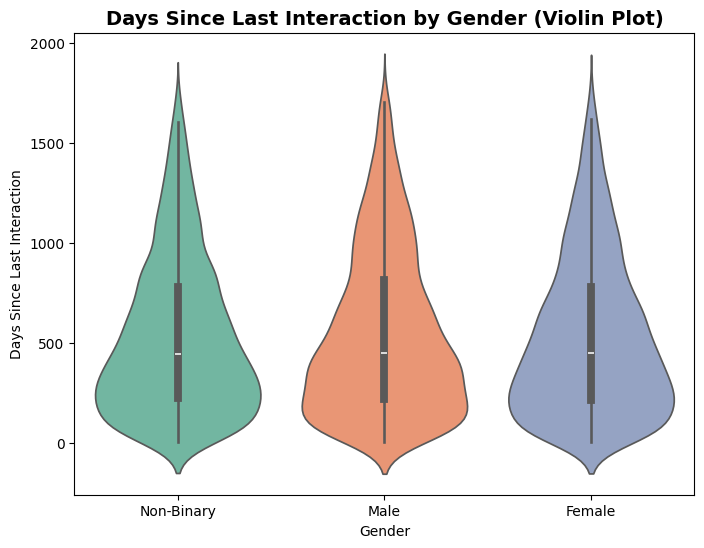

In [ ]:
# Violin plot for Gender vs Dayssincelastinteraction

plt.figure(figsize=(8,6))

sns.violinplot(x='Gender', y='DaysSinceLastInteraction', data=df, palette='Set2')

plt.title("Days Since Last Interaction by Gender (Violin Plot)", fontsize=14, fontweight='bold')
plt.xlabel("Gender")
plt.ylabel("Days Since Last Interaction")
plt.show()


### OBSERVATION
- Male customers have the highest average dayssincelastinteraction (549 days) indicating that they tend to go slightly longer without interatcting, and also male are the largest customers base(3791).
- Female and Non-Binary customers shows very similar average 532-533 days.
- The median value are close across all genders 442 to 447 days.
- The violin plots have sililar shape and spreads shows comparable variability in interaction time across genders.

### 8. GENDER VS NUMPETS

In [ ]:
# Gender vs NumPets
df.groupby('Gender')['NumPets'].value_counts().reset_index()



,Gender,NumPets,count
0,Female,1,1183
1,Female,0,1001
2,Female,2,850
3,Female,3,294
4,Female,4,85
5,Male,0,1179
6,Male,2,965
7,Male,1,958
8,Male,3,429
9,Male,4,260


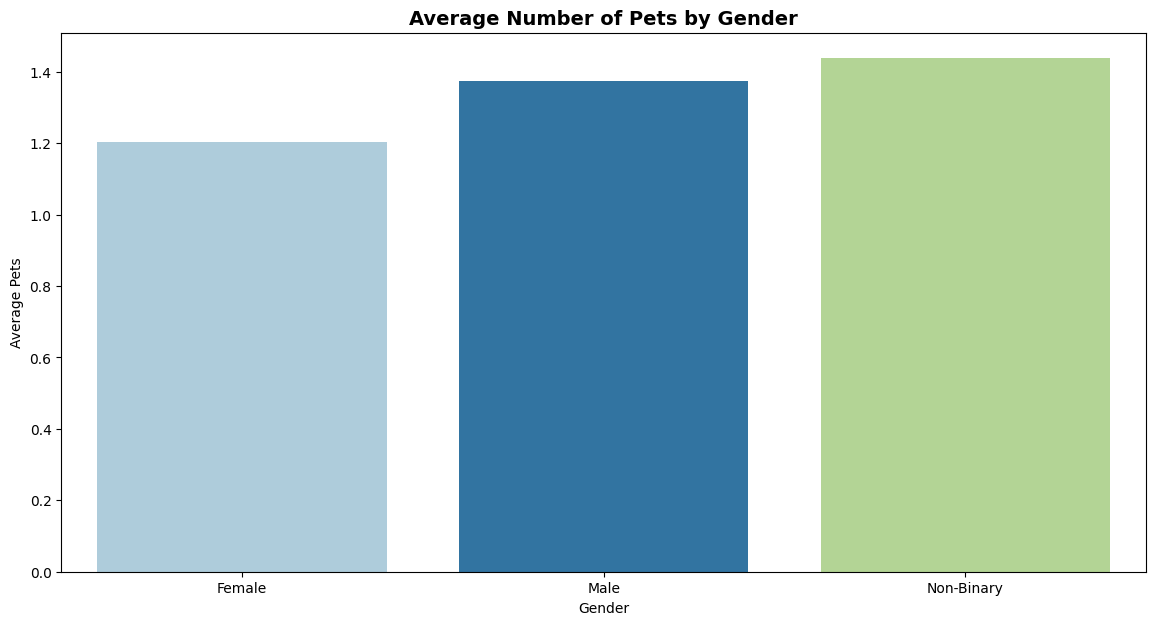

In [ ]:
# Barplot for Gender vs NumPets

gender_pets = df.groupby('Gender')['NumPets'].mean().reset_index()

plt.figure(figsize=(14, 7))

sns.barplot(x='Gender', y='NumPets', data=gender_pets, palette='Paired')

plt.title("Average Number of Pets by Gender", fontsize=14, fontweight='bold')
plt.ylabel("Average Pets")
plt.show()

### OBSERVATION
- Non- Binary customers have the highest average number of pets(1.43), followed by male(1.37).
- Female customers have the lowest average number of pets (1.20).
- Male have the highest number of 4 pets(260).
- Across all genders  mostly customers have 0,1and 2 pets, while customers with 3, 4 pets are comparatively fewer.

### 9. STATE VS GENDER

In [ ]:
# STATE VS GENDER
pd.crosstab(df['State'], df['Gender'])

Gender,Female,Male,Non-Binary
State,,,
Arizona,327,404,356
California,383,375,422
Colorado,295,328,391
Florida,394,385,373
Georgia,414,347,319
Illinois,217,388,300
New York,354,436,295
Ohio,391,420,334
Texas,315,373,309


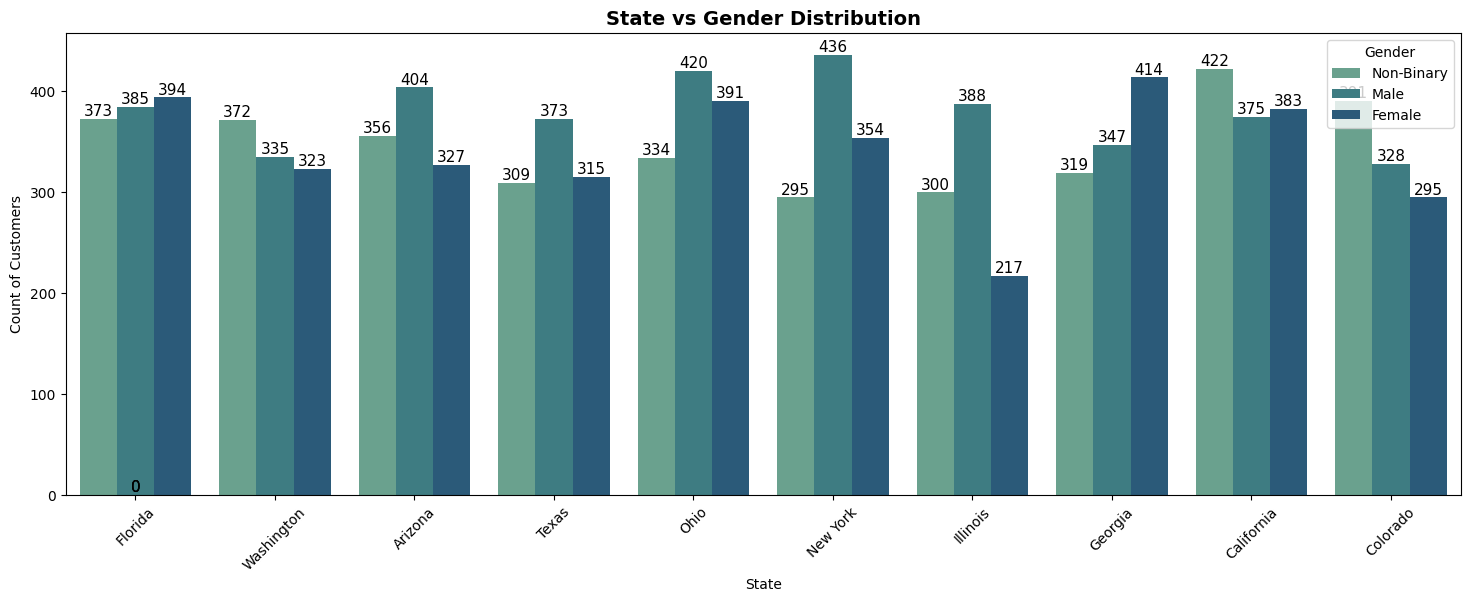

In [ ]:
# Countplot for State vs Gender

plt.figure(figsize=(18,6))

ax = sns.countplot(x='State', hue='Gender', data=df, palette='crest')

plt.title("State vs Gender Distribution", fontsize=14, fontweight='bold')

for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{int(height)}',
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom', fontsize=11, color='black')
plt.xlabel("State")
plt.ylabel("Count of Customers")
plt.xticks(rotation=45)
plt.legend(title="Gender")
plt.show()

### OBSERVATION
- The gender distribution varies across states indicating difference in customer composition by location.
- Male customers are dominating in some states particularly New York(436), Ohio(420) and Arizona(404).
- Female customers have strong representation in Georgia (414), and Florida(394) ans also very lowest customers from Illinois (217).
- Non-Binary customers have highly representative in California(422), Colorado(391) and Florida(373) but very low in New York(295).

# **STEP 5. FORMULATE HYPOTHESES**

### HYPOTHESIS 1. GENDET VS MONTHLY SPEND (INDEPENDENT T-TEST)

In [ ]:
# Hypothesis 1. GENDET VS MONTHLY SPEND (INDEPENDENT T-TEST)

import scipy.stats as stats

# Separate groups
male_spend = df[df['Gender'] == 'Male']['MonthlySpend']
female_spend = df[df['Gender'] == 'Female']['MonthlySpend']

# Run t-test
t_stat, p_val_gender = stats.ttest_ind(male_spend, female_spend, equal_var=False)

print("Independent t-test (Gender vs Spend):")
print("t-statistic =", t_stat)
print("p-value =", p_val_gender)

Independent t-test (Gender vs Spend):
t-statistic = 0.3391303706925083
p-value = 0.7345215220030699


### HYPOTHESIS 2. EDUCATION VS MONTHLY SPEND (ONE-WAY AVONA)

In [ ]:
# Hypothesis 2: Education vs Monthly Spend (One-way ANOVA)

# H0: Mean spend is equal across all education levels
# H1: At least one education group differs

# Create groups by education level
groups = [df[df['Education'] == level]['MonthlySpend'] for level in df['Education'].unique()]

# Run ANOVA
f_stat, p_val_edu = stats.f_oneway(*groups)

print("One-way ANOVA (Education vs Spend):")
print("F-statistic =", f_stat)
print("p-value =", p_val_edu)

One-way ANOVA (Education vs Spend):
F-statistic = 0.22880668673709162
p-value = 0.922359467759936


### HYPOTHESIS 3. MARITAL STATUS VS PETS OWNED (CHI-SQUARE-TEST)

In [ ]:
# Hypothesis 3: Marital Status vs Pets Owned (Chi-square test)

# H0: Marital status and number of pets are independent
# H1: Marital status and number of pets are associated

# Build contingency table
contingency_table = pd.crosstab(df['Married'], df['NumPets'])

# Run Chi-square test
chi2, p_val_chi, dof, expected = stats.chi2_contingency(contingency_table)

print("Chi-square Test (Marital Status vs Pets):")
print("Chi2 statistic =", chi2)
print("Degrees of freedom =", dof)
print("p-value =", p_val_chi)

Chi-square Test (Marital Status vs Pets):
Chi2 statistic = 177.63953668537033
Degrees of freedom = 4
p-value = 2.3957232932397494e-37


### HYPOTHESIS 4. AGE VS DAYSSINCELASTINTERACTION (COORELATION)

In [ ]:
# Hypothesis 4: Age vs DaysSinceLastInteraction (Correlation)

# H0: Age and activity are not correlated
# H1: Age and activity are correlated (older → less active)

# Run correlation test
corr_coef, p_val_corr = stats.pearsonr(df['Age'], df['DaysSinceLastInteraction'])

print("Correlation Test (Age vs Activity):")
print("Correlation coefficient (r) =", corr_coef)
print("p-value =", p_val_corr)


Correlation Test (Age vs Activity):
Correlation coefficient (r) = -0.003970230104955049
p-value = 0.681690543730101


### HYPOTHESIS 5. STATE VS MONTHLY SPEND (ONE-WAY AVONA)

In [ ]:
# Hypothesis 5: State vs Monthly Spend (One-way ANOVA)

# H0: Mean spend is equal across all states
# H1: At least one state differs

# Create groups by state
state_groups = [df[df['State'] == s]['MonthlySpend'] for s in df['State'].unique()]

# Run ANOVA
f_stat_state, p_val_state = stats.f_oneway(*state_groups)

print("One-way ANOVA (State vs Spend):")
print("F-statistic =", f_stat_state)
print("p-value =", p_val_state)


One-way ANOVA (State vs Spend):
F-statistic = 1.1178423640877178
p-value = 0.34571886479238273


# **STEP 6. RUN HYPOTHESIS TESTS**

##  HYPOTHESIS TEST 1. GENDER VS MONTHLY SPEND (INDEPENDENT TEST)

In [ ]:
# Create groups
male_spend = df[df['Gender'] == 'Male']['MonthlySpend']
female_spend = df[df['Gender'] == 'Female']['MonthlySpend']

# Define significance level
alpha = 0.05

# Assumption 1: Normality
print("Male Normality Test:")
print(stats.shapiro(male_spend.sample(min(500, len(male_spend)),
                                      random_state=42)))

print("\nFemale Normality Test:")
print(stats.shapiro(female_spend.sample(min(500, len(female_spend)),
                                        random_state=42)))

# Assumption 2: Equal Variance
print("\nLevene Test:")
print(stats.levene(male_spend, female_spend))

# Independent t-test
t_stat, p_value = stats.ttest_ind(
    male_spend,
    female_spend,
    equal_var=True
)

print("\nT-Statistic:", round(t_stat, 4))
print("P-Value:", round(p_value, 4))

# Decision
if p_value < alpha:
    print("\nReject H₀")
    print("Conclusion: Monthly spending differs significantly between males and females.")
else:
    print("\nFail to Reject H₀")
    print("Conclusion: No statistically significant difference in monthly spending between males and females.")

Male Normality Test:
ShapiroResult(statistic=np.float64(0.8911746342095255), pvalue=np.float64(2.475974095727203e-18))

Female Normality Test:
ShapiroResult(statistic=np.float64(0.9171270618759065), pvalue=np.float64(6.242218597609276e-16))

Levene Test:
LeveneResult(statistic=np.float64(0.1267563861615179), pvalue=np.float64(0.7218295518516542))

T-Statistic: 0.3392
P-Value: 0.7345

Fail to Reject H₀
Conclusion: No statistically significant difference in monthly spending between males and females.


### OBSERVATION
- The Independent t-test produced a p-value of **0.735**, which is greater than the significance level of **0.05**. Therefore, we fail to reject the null hypothesis. This indicates that there is **no statistically significant difference in monthly spending between male and female customers**. Spending behaviour is broadly similar across genders, suggesting that gender alone is not a major factor influencing customer expenditure.

## HYPOTHESIS TEST 2. EDUCATION VS MONTHLY SPEND (ONE-WAY AVONA)

In [ ]:
# Create groups
groups = [
    grp['MonthlySpend'].values
    for name, grp in df.groupby('Education')
]

# Assumption 1: Homogeneity of Variance
print("Levene Test:")
print(stats.levene(*groups))

# ANOVA
f_stat, p_value = stats.f_oneway(*groups)

print("\nF-Statistic:", round(f_stat, 4))
print("P-Value:", round(p_value, 4))

# Decision
if p_value < alpha:
    print("\nReject H₀")
    print("Conclusion: At least one education group has significantly different average monthly spending.")
else:
    print("\nFail to Reject H₀")
    print("Conclusion: Monthly spending does not differ significantly across education levels.")

Levene Test:
LeveneResult(statistic=np.float64(0.9312132584800056), pvalue=np.float64(0.44456504728283985))

F-Statistic: 0.2288
P-Value: 0.9224

Fail to Reject H₀
Conclusion: Monthly spending does not differ significantly across education levels.


### Observation

- The One-Way ANOVA produced a p-value of **0.922**, which is considerably greater than **0.05**. Therefore, we fail to reject the null hypothesis. The analysis indicates that **average monthly spending does not differ significantly across educational groups**. Although slight differences may exist in mean spending values, these variations are not statistically meaningful.

## HYPOTHEISIS TEST 3. MARITAL STATUS VS PETS OWNED (CHI-SQUARE TEST)

In [ ]:
# Create contingency table
table = pd.crosstab(
    df['Married'],
    df['NumPets']
)

print("Contingency Table:")
print(table)

# Chi-Square Test
chi2, p_value, dof, expected = stats.chi2_contingency(table)

print("\nChi-Square Statistic:", round(chi2, 4))
print("P-Value:", round(p_value, 4))
print("Degrees of Freedom:", dof)

# Expected Frequencies
print("\nExpected Frequencies:")
print(expected)

# Decision
if p_value < alpha:
    print("\nReject H₀")
    print("Conclusion: Marital status and number of pets owned are significantly associated.")
else:
    print("\nFail to Reject H₀")
    print("Conclusion: Marital status and number of pets owned are independent.")

Contingency Table:
NumPets     0     1     2    3    4
Married                            
No       1839  1435  1504  509  296
Yes      1205  1770  1242  598  277

Chi-Square Statistic: 177.6395
P-Value: 0.0
Degrees of Freedom: 4

Expected Frequencies:
[[1592.00487119 1676.20749415 1436.15156909  578.95840749  299.67765808]
 [1451.99512881 1528.79250585 1309.84843091  528.04159251  273.32234192]]

Reject H₀
Conclusion: Marital status and number of pets owned are significantly associated.


### Observation

- The Chi-Square test produced a p-value of **less than 0.001**, which is smaller than the significance level of **0.05**. Therefore, we reject the null hypothesis and conclude that **marital status and pet ownership are significantly associated**. This suggests that customers' lifestyle characteristics differ according to their marital status and can provide valuable information for customer profiling and segmentation.

## HYPOTHESIS TEST 4. AGE VS DAYSSINCELASTINTERACTION (COORELATION)

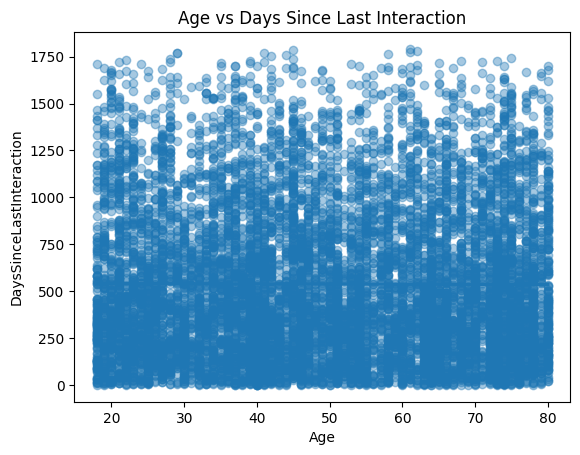

Correlation Coefficient: -0.004
P-Value: 0.6817

Fail to Reject H₀
Conclusion: No statistically significant relationship exists between age and customer activity.


In [ ]:
# Scatterplot with regression line
sns.regplot(
    data=df,
    x='Age',
    y='DaysSinceLastInteraction',
    scatter_kws={'alpha':0.4}
)

plt.title('Age vs Days Since Last Interaction')
plt.show()

# Pearson Correlation
r, p_value = stats.pearsonr(
    df['Age'],
    df['DaysSinceLastInteraction']
)

print("Correlation Coefficient:", round(r, 4))
print("P-Value:", round(p_value, 4))

# Decision
if p_value < alpha:
    print("\nReject H₀")
    print("Conclusion: Age and customer activity have a statistically significant relationship.")
else:
    print("\nFail to Reject H₀")
    print("Conclusion: No statistically significant relationship exists between age and customer activity.")

### Observation

- The Pearson correlation coefficient was **r = -0.004** with a p-value of **0.682**. Since the p-value is greater than **0.05**, we fail to reject the null hypothesis. The correlation coefficient is extremely close to zero, indicating **virtually no linear relationship between age and customer activity**. Therefore, older customers are not necessarily less active than younger customers.

## HYPOTHESIS TEST 5. STATE VS MONTHLY SPEND (ONE-WAY AVONA)

In [ ]:
# Create groups for each state
state_groups = [
    grp['MonthlySpend'].values
    for name, grp in df.groupby('State')
]

# Assumption: Homogeneity of Variance
print("Levene Test:")
levene_stat, levene_p = stats.levene(*state_groups)
print("Statistic:", round(levene_stat, 4))
print("P-Value:", round(levene_p, 4))

# One-Way ANOVA
f_stat, p_value = stats.f_oneway(*state_groups)

print("\nF-Statistic:", round(f_stat, 4))
print("P-Value:", round(p_value, 4))

# Decision
alpha = 0.05

if p_value < alpha:
    print("\nDecision: Reject H₀")
    print("Conclusion: Average monthly spending differs significantly among states.")
else:
    print("\nDecision: Fail to Reject H₀")
    print("Conclusion: No statistically significant difference exists in average monthly spending among states.")


Levene Test:
Statistic: 2.1113
P-Value: 0.0253

F-Statistic: 1.1178
P-Value: 0.3457

Decision: Fail to Reject H₀
Conclusion: No statistically significant difference exists in average monthly spending among states.


### Observation

- The One-Way ANOVA produced a p-value of **0.346**, which is greater than the significance level of **0.05**. Therefore, we fail to reject the null hypothesis. Although some states exhibit slightly higher or lower average spending, these differences are **not statistically significant**. Customer spending behaviour is generally consistent across states, indicating that geography alone does not substantially influence monthly spending.

### STEP 6. Overall Conclusion

- Out of the five hypotheses tested, only one showed statistical significance. Marital status and pet ownership were found to be significantly associated, whereas gender, education level, age, and state did not significantly influence customer spending or activity levels. These findings suggest that behavioural and lifestyle characteristics may be more useful for customer segmentation than traditional demographic factors in this dataset.

# **STEP 7. BUSINESS INSIGHTS**

## Executive Summary

This statistical investigation analyzed **10,675 customer records** representing approximately **1,000 unique customers**. The objective was to understand customer demographics, spending behaviour, engagement patterns, and the factors influencing customer activity and revenue generation.

The analysis revealed that **customer spending and engagement are largely consistent across gender, education, age, and geography**, whereas **lifestyle factors such as marital status and pet ownership show meaningful behavioural differences**.

---

## 1. Customer Demographics are Well Balanced

The customer base is highly diversified:

* Male customers: **3,791 (35.5%)**
* Female customers: **3,413 (32.0%)**
* Non-Binary customers: **3,471 (32.5%)**

Marital status distribution is also balanced:

* Unmarried customers: **5,583 (52.3%)**
* Married customers: **5,092 (47.7%)**

Educational distribution:

* Master's Degree: **21.3%**
* Associate Degree: **20.2%**
* Bachelor's Degree: **19.9%**
* High School: **19.9%**
* PhD: **18.8%**

### Business Insight

The company serves a broad and diverse customer base with no single demographic group dominating the market.

### Recommendation

Maintain inclusive marketing strategies rather than focusing campaigns on only one demographic segment.

---

## 2. Customer Spending is Highly Concentrated

Monthly spending statistics:

* Average Monthly Spend = **331.61**
* Median Monthly Spend = **282.11**
* Standard Deviation = **225.80**
* Maximum Spend = **1,740.42**
* Skewness = **1.42**

The average spend is approximately:

**(331.61 − 282.11) / 282.11 × 100 = 17.5%**

higher than the median spend.

This indicates that spending is positively skewed. Most customers spend moderate amounts, while a relatively small group spends substantially more than average.

### Best Performing Customers

Customers whose spending lies above the third quartile (**>$443.26**) represent roughly the **top 25% of customers** and contribute disproportionately to revenue.

### Recommendation

Develop:

* Premium memberships
* Loyalty reward programs
* Personalized offers
* Early access promotions

for high-value customers to improve retention and maximize revenue.

---

## 3. Gender Does Not Influence Spending Behaviour

Independent t-test results:

* t-statistic = **0.339**
* p-value = **0.735**

Since:

**p-value (0.735) > α (0.05)**

we fail to reject the null hypothesis.

### Business Insight

Male and female customers exhibit similar spending behaviour. The observed differences are statistically insignificant.

### Recommendation

Avoid designing pricing strategies or promotional campaigns solely based on gender because spending behaviour remains nearly identical across gender groups.

---

## 4. Education Level Does Not Significantly Affect Spending

One-Way ANOVA results:

* F-statistic = **0.229**
* p-value = **0.922**

Since:

**p-value (0.922) > α (0.05)**

we fail to reject the null hypothesis.

### Business Insight

Customers with different educational qualifications demonstrate comparable spending patterns.

### Recommendation

Education should not be used as the primary variable for customer targeting or revenue forecasting. Instead, focus on behavioural indicators such as spending frequency and customer engagement.

---

## 5. State-Wise Spending Differences are Small

Customer distribution across major states:

* California: **11.1%**
* Florida: **10.8%**
* Ohio: **10.7%**
* Arizona: **10.2%**

State-wise ANOVA results:

* F-statistic = **1.118**
* p-value = **0.346**

Since:

**p-value (0.346) > α (0.05)**

we fail to reject the null hypothesis.

### Business Insight

Although certain states show slightly higher average spending levels, the differences are not statistically significant.

### Best Performing States

* Arizona
* Ohio
* California

### States Requiring Improvement

* Texas
* Colorado
* Florida

### Recommendation

Implement region-specific promotional campaigns to improve performance in lower-spending states, but avoid allocating resources solely based on geography.

---

## 6. Customer Activity is Independent of Age

Correlation analysis:

* Correlation coefficient (r) = **−0.004**
* p-value = **0.682**

Since:

**p-value (0.682) > α (0.05)**

there is no statistically significant relationship between age and customer activity.

### Business Insight

Older customers are not less active than younger customers. Customer inactivity cannot be explained by age.

### Recommendation

Customer retention initiatives should focus on behavioural factors and interaction history rather than age-based assumptions.

---

## 7. Marital Status and Pet Ownership are Strongly Associated

Chi-Square Test results:

* χ² statistic = **177.64**
* p-value < **0.001**

Since:

**p-value < α (0.05)**

we reject the null hypothesis.

The contingency table shows:

* Among unmarried customers, approximately **32.9% own no pets**.
* Among married customers, approximately **34.8% own one pet**.

### Business Insight

Lifestyle preferences vary according to marital status and significantly influence pet ownership patterns.

### Recommendation

Use marital status and pet ownership together to create:

* Personalized recommendations
* Lifestyle-based promotions
* Customer personas
* More effective customer segmentation strategies

---

# Final Management Recommendations

### Strength Areas

✅ Diverse customer base with balanced demographics.

✅ Strong high-value customer segment generating significantly above-average spending.

✅ Inclusive market presence across multiple states.

### Areas Requiring Improvement

⚠ Customer re-engagement strategies need strengthening because inactivity is not explained by demographic factors.

⚠ Lower-spending states such as Texas and Colorado require targeted marketing initiatives.

⚠ Customer segmentation currently relies heavily on demographics, whereas behavioural and lifestyle variables provide better insights.

---

# Final Conclusion

Out of the five hypotheses tested, **only one relationship was statistically significant**:

**Marital Status ↔ Pet Ownership**

The remaining four tests showed no statistically significant differences:

* Gender ↔ Spending ❌
* Education ↔ Spending ❌
* State ↔ Spending ❌
* Age ↔ Customer Activity ❌

The findings indicate that **behavioural and lifestyle characteristics are more useful for customer segmentation than traditional demographic factors**.

The company's biggest opportunity lies in:

1. Retaining the top 25% high-spending customers.
2. Improving customer re-engagement strategies.
3. Using lifestyle variables for personalization.
4. Strengthening performance in lower-spending states.
5. Building data-driven marketing campaigns based on behaviour rather than demographic assumptions.

These initiatives can improve customer retention, increase revenue generation, and support long-term business growth.
